# Import Libraries

In [1]:
import math
import os
import pprint
from collections import Counter
from contextlib import redirect_stdout

import matplotlib.animation as animation
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pylidc as pl
import seaborn as sns

from pylidc.utils import consensus
from skimage.measure import find_contours
from sqlalchemy import and_
from tabulate import tabulate
from tqdm import tqdm

c:\Users\filli\anaconda3\envs\nodule_py310\lib\site-packages\pylidc\__init__.py:27: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources as _pr


In [2]:
sns.set_theme(
    style="whitegrid",
    palette="Set2",
    context="notebook"
)

# Explore NBIA Digest Data (XLSX)

## Load Data

In [3]:
nbia_digest_df = pd.read_excel("../../dataset/_lidc/000_metadata/TCIA_LIDC-IDRI_20200921-nbia-digest.xlsx")
nbia_digest_df.columns = (
    nbia_digest_df.columns
    .str.lower()
    .str.replace(" ", "_", regex=False)
)

print(f"{'='*20} DataFrame Information {'='*20}")
nbia_digest_df.info()
print(f"\n{'='*20} First 5 Rows Of A DataFrame {'='*20}")
display(nbia_digest_df.head())

==================== DataFrame Information ====================
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1308 entries, 0 to 1307
Data columns (total 36 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   patient_id                               1308 non-null   object 
 1   patient_name                             0 non-null      float64
 2   patient_birth_date                       0 non-null      float64
 3   patient_sex                              451 non-null    object 
 4   ethnic_group                             61 non-null     object 
 5   phantom                                  1308 non-null   object 
 6   species_code                             1308 non-null   int64  
 7   species_description                      1308 non-null   object 
 8   study_instance_uid                       1308 non-null   object 
 9   study_date                               1308 non-null

,patient_id,patient_name,patient_birth_date,patient_sex,ethnic_group,phantom,species_code,species_description,study_instance_uid,study_date,...,manufacturer_model_name,software_versions,image_count,max_submission_timestamp,license_name,license_uri,collection_uri,file_size,date_released,third_party_analysis
0,LIDC-IDRI-0001,NaN,NaN,NaN,NaN,NO,337915000,Homo sapiens,1.3.6.1.4.1.14519.5.2.1.6279.6001.175012972118...,2000-01-01 00:00:00.0,...,Revolution XQi ADS_28.2,Ads Application Package VERSION ADS_28.2,2,2020-02-21 15:12:42.0,Creative Commons Attribution 3.0 Unported License,http://creativecommons.org/licenses/by/3.0/,https://doi.org/10.7937/K9/TCIA.2015.LO9QL9SX,16357620,2020-02-21 15:12:42.0,NaN
1,LIDC-IDRI-0001,NaN,NaN,NaN,NaN,NO,337915000,Homo sapiens,1.3.6.1.4.1.14519.5.2.1.6279.6001.298806137288...,2000-01-01 00:00:00.0,...,LightSpeed Plus,LightSpeedApps2.4.2_H2.4M5,133,2020-02-21 15:12:49.0,Creative Commons Attribution 3.0 Unported License,http://creativecommons.org/licenses/by/3.0/,https://doi.org/10.7937/K9/TCIA.2015.LO9QL9SX,70018838,2020-02-21 15:12:49.0,NaN
2,LIDC-IDRI-0002,NaN,NaN,NaN,NaN,NO,337915000,Homo sapiens,1.3.6.1.4.1.14519.5.2.1.6279.6001.116951808801...,2000-01-01 00:00:00.0,...,Revolution XRd ADS_27.5.4,Ads Application Package VERSION ADS_27.5.4,1,2020-02-21 15:12:48.0,Creative Commons Attribution 3.0 Unported License,http://creativecommons.org/licenses/by/3.0/,https://doi.org/10.7937/K9/TCIA.2015.LO9QL9SX,6909958,2020-02-21 15:12:48.0,NaN
3,LIDC-IDRI-0002,NaN,NaN,NaN,NaN,NO,337915000,Homo sapiens,1.3.6.1.4.1.14519.5.2.1.6279.6001.490157381160...,2000-01-01 00:00:00.0,...,LightSpeed16,06MW03.5,261,2020-02-21 15:13:03.0,Creative Commons Attribution 3.0 Unported License,http://creativecommons.org/licenses/by/3.0/,https://doi.org/10.7937/K9/TCIA.2015.LO9QL9SX,137396696,2020-02-21 15:13:03.0,NaN
4,LIDC-IDRI-0003,NaN,NaN,NaN,NaN,NO,337915000,Homo sapiens,1.3.6.1.4.1.14519.5.2.1.6279.6001.101370605276...,2000-01-01 00:00:00.0,...,LightSpeed16,06MW03.5,140,2020-02-21 15:13:11.0,Creative Commons Attribution 3.0 Unported License,http://creativecommons.org/licenses/by/3.0/,https://doi.org/10.7937/K9/TCIA.2015.LO9QL9SX,73704090,2020-02-21 15:13:11.0,NaN


## EDA Dashboard

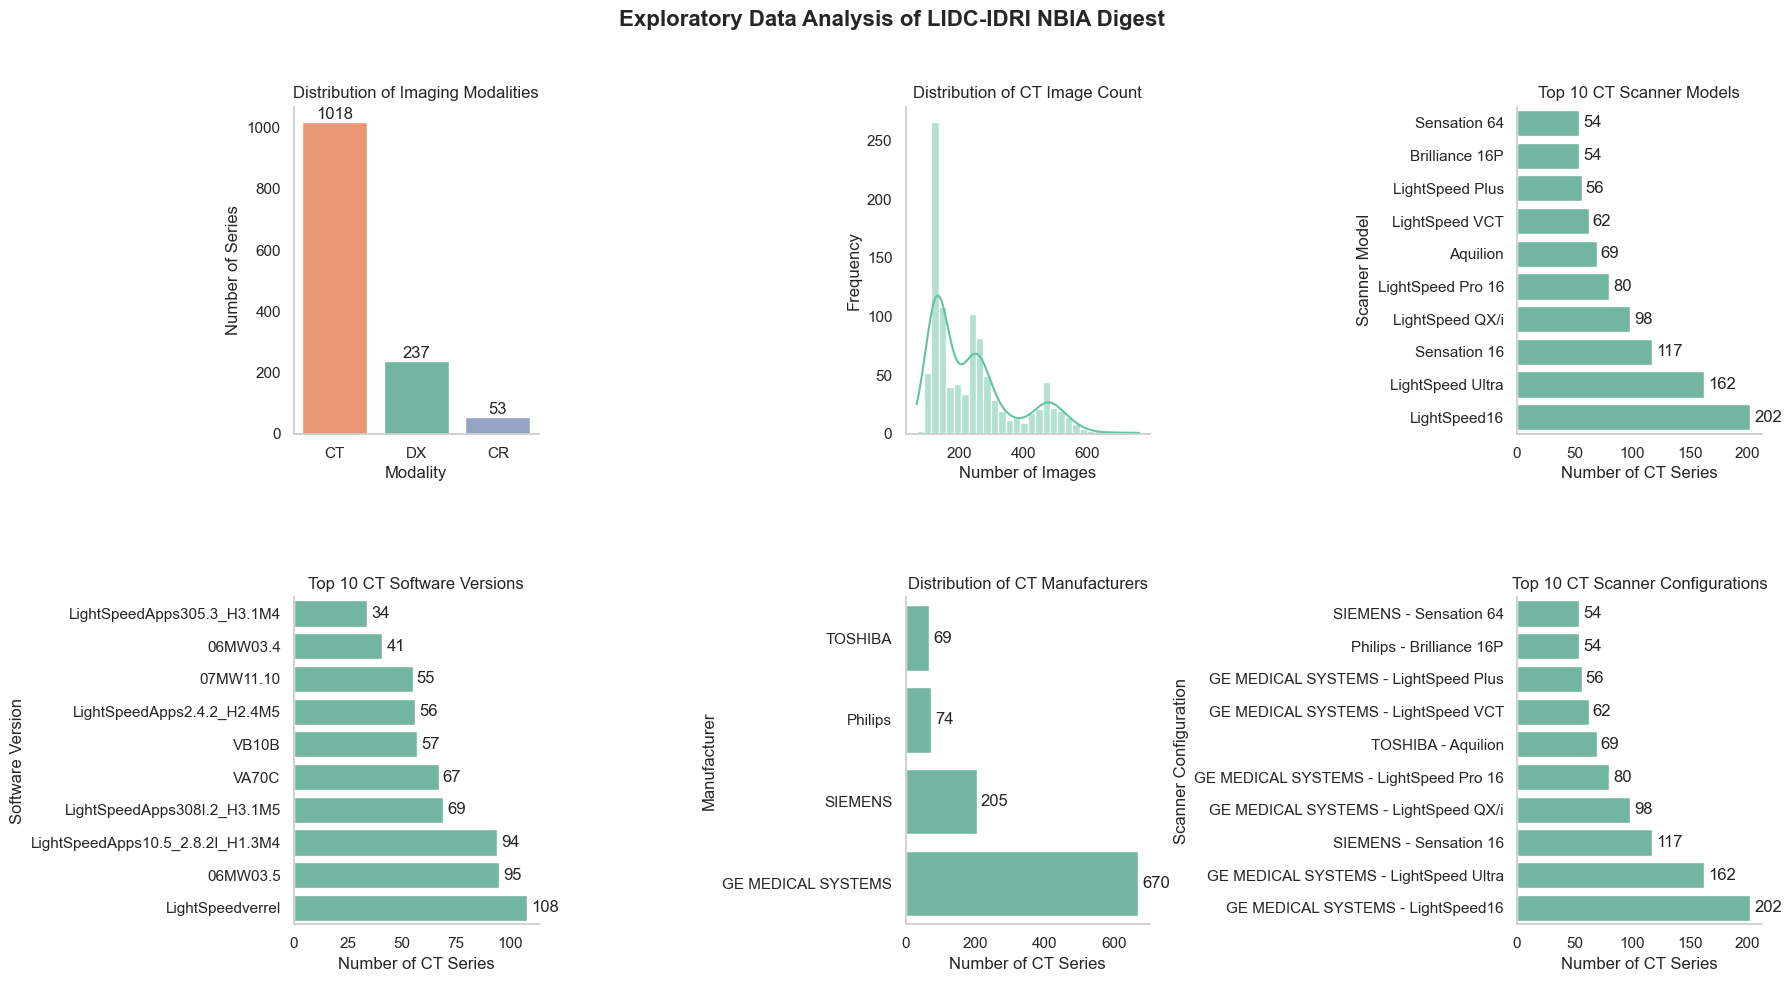

In [4]:
# Filter CT only
ct_df = nbia_digest_df[nbia_digest_df["modality"] == "CT"].copy()

# Dashboard Layout
n_charts = 6
n_cols = 3
n_rows = math.ceil(n_charts / n_cols)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(6 * n_cols, 5 * n_rows)
)

fig.suptitle(
    "Exploratory Data Analysis of LIDC-IDRI NBIA Digest",
    fontsize=16,
    fontweight="bold"
)

axes = axes.flatten()

# Imaging Modalities
ax = axes[0]

sns.countplot(
    data=nbia_digest_df,
    x="modality",
    hue="modality",
    order=nbia_digest_df["modality"].value_counts().index,
    legend=False,
    ax=ax
)

ax.set_title("Distribution of Imaging Modalities")
ax.set_xlabel("Modality")
ax.set_ylabel("Number of Series")

for container in ax.containers:
    ax.bar_label(container)

sns.despine(ax=ax)

# CT Manufacturers
ax = axes[4]

manufacturer_counts = (
    ct_df["manufacturer"]
    .value_counts()
    .sort_values()
)

sns.barplot(
    x=manufacturer_counts.values,
    y=manufacturer_counts.index,
    ax=ax
)

ax.set_title("Distribution of CT Manufacturers")
ax.set_xlabel("Number of CT Series")
ax.set_ylabel("Manufacturer")

for container in ax.containers:
    ax.bar_label(container, padding=3)

sns.despine(ax=ax)

# Top 10 CT Scanner Models
ax = axes[2]

scanner_model_counts = (
    ct_df["manufacturer_model_name"]
    .value_counts()
    .head(10)
    .sort_values()
)

sns.barplot(
    x=scanner_model_counts.values,
    y=scanner_model_counts.index,
    ax=ax
)

ax.set_title("Top 10 CT Scanner Models")
ax.set_xlabel("Number of CT Series")
ax.set_ylabel("Scanner Model")

for container in ax.containers:
    ax.bar_label(container, padding=3)

sns.despine(ax=ax)

# Top 10 CT Software Versions
ax = axes[3]

software_counts = (
    ct_df["software_versions"]
    .value_counts()
    .head(10)
    .sort_values()
)

sns.barplot(
    x=software_counts.values,
    y=software_counts.index,
    ax=ax
)

ax.set_title("Top 10 CT Software Versions")
ax.set_xlabel("Number of CT Series")
ax.set_ylabel("Software Version")

for container in ax.containers:
    ax.bar_label(container, padding=3)

sns.despine(ax=ax)

# Distribution of CT Image Count
ax = axes[1]

sns.histplot(
    data=ct_df,
    x="image_count",
    bins=30,
    kde=True,
    ax=ax
)

ax.set_title("Distribution of CT Image Count")
ax.set_xlabel("Number of Images")
ax.set_ylabel("Frequency")

sns.despine(ax=ax)

# Top 10 CT Scanner Configurations
ax = axes[5]

ct_df["scanner_configuration"] = (
    ct_df["manufacturer"] +
    " - " +
    ct_df["manufacturer_model_name"]
)

scanner_config_counts = (
    ct_df["scanner_configuration"]
    .value_counts()
    .head(10)
    .sort_values()
)

sns.barplot(
    x=scanner_config_counts.values,
    y=scanner_config_counts.index,
    ax=ax
)

ax.set_title("Top 10 CT Scanner Configurations")
ax.set_xlabel("Number of CT Series")
ax.set_ylabel("Scanner Configuration")

for container in ax.containers:
    ax.bar_label(container, padding=3)

sns.despine(ax=ax)

# Final Layout
for ax in axes:
    ax.grid(False)

fig.tight_layout(rect=[0, 0, 1, 0.96])
fig.subplots_adjust(
    wspace=1.5,
    hspace=0.5
)
plt.show()

- CT is the dominant imaging modality in the LIDC-IDRI collection, accounting for 1,018 series, while DX (237) and CR (53) comprise a much smaller portion of the dataset.
- The distribution of CT image counts shows noticeable variability, with most CT series containing approximately 100–300 slices, while a smaller number of scans contain more than 500 slices.

# Explore Nodule Counts Data (XLSX)

## Load Data

- *total number of lesions that received either a "nodule < 3mm" mark or a "nodule >= 3mm" mark from at least one of the four LIDC radiologists
- **total number of lesions that received a "nodule >= 3mm" mark from at least one of the four LIDC radiologists (regardless of how the other radiologists marked the lesion)
- ***total number of lesions that received a "nodule < 3mm" mark from at least one of the four LIDC radiologists (with no radiologist assigning the lesion a "nodule >= 3mm" mark)

In [5]:
nodule_counts = pd.read_excel("../../dataset/_lidc/000_metadata/lidc-idri-nodule-counts-6-23-2015.xlsx")
nodule_counts.columns = (
    nodule_counts.columns
    .str.lower()
    .str.replace(" ", "_", regex=False)
)

print(f"{'='*20} DataFrame Information {'='*20}")
nodule_counts.info()
print(f"\n{'='*20} First 5 Rows Of A DataFrame {'='*20}")
display(nodule_counts.head())

==================== DataFrame Information ====================
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1018 entries, 0 to 1017
Data columns (total 4 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   tcia_patent_id             1018 non-null   object
 1   total_number_of_nodules*   1018 non-null   int64 
 2   number_of_nodules_>=3mm**  1018 non-null   int64 
 3   number_of_nodules_<3mm***  1018 non-null   int64 
dtypes: int64(3), object(1)
memory usage: 31.9+ KB

==================== First 5 Rows Of A DataFrame ====================


,tcia_patent_id,total_number_of_nodules*,number_of_nodules_>=3mm**,number_of_nodules_<3mm***
0,LIDC-IDRI-0001,4,1,3
1,LIDC-IDRI-0002,12,1,11
2,LIDC-IDRI-0003,4,4,0
3,LIDC-IDRI-0004,4,1,3
4,LIDC-IDRI-0005,9,3,6


## EDA Dashboard

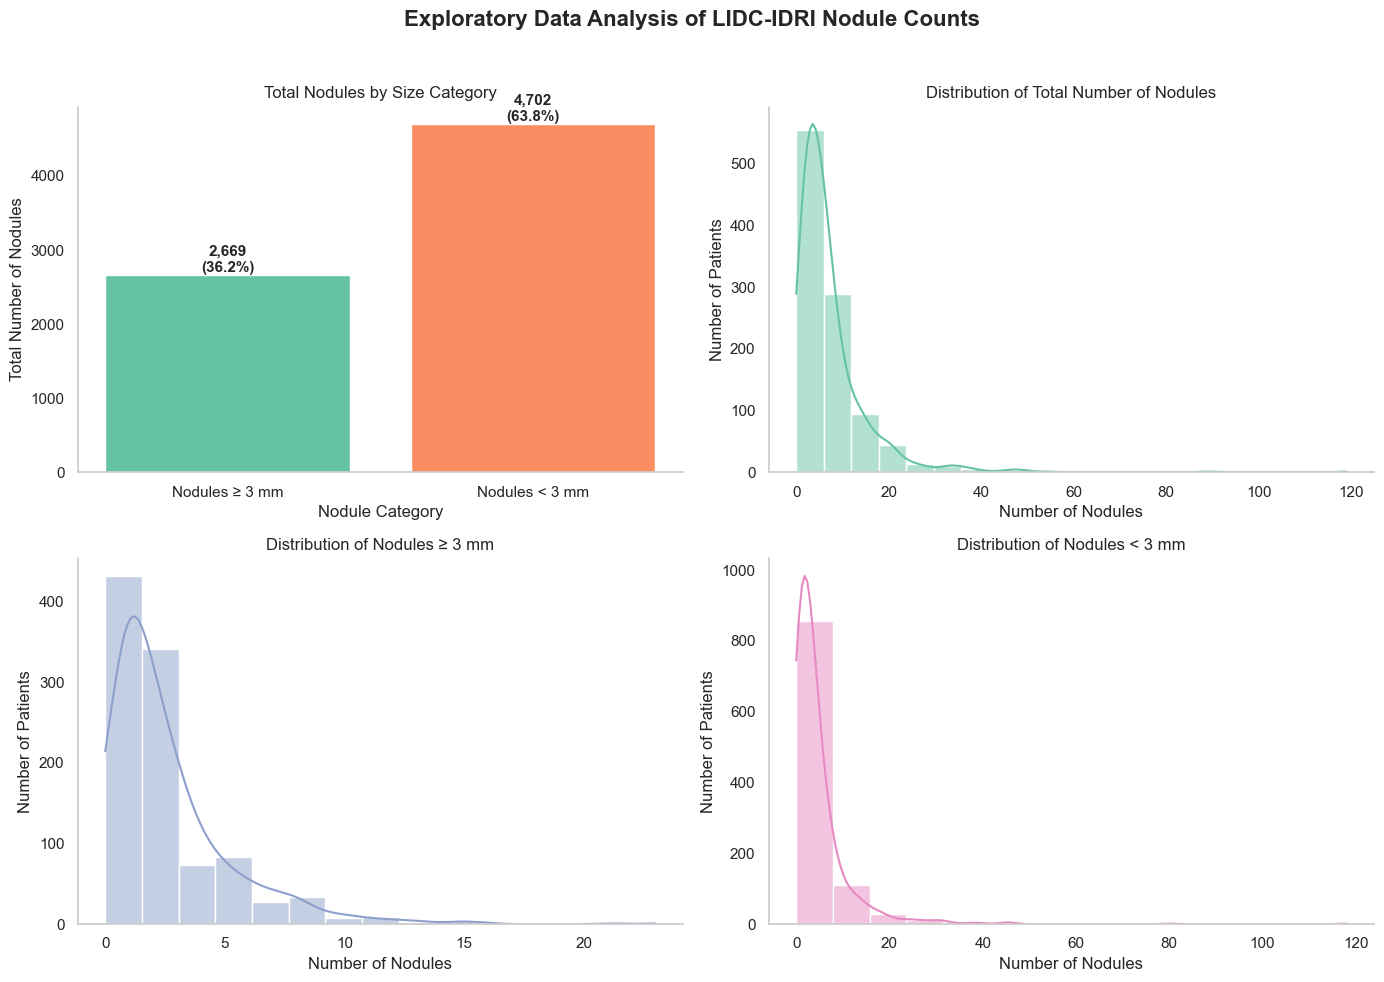

In [6]:
# Dashboard Layout
n_charts = 4
n_cols = 2
n_rows = math.ceil(n_charts / n_cols)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(14, 10)
)

fig.suptitle(
    "Exploratory Data Analysis of LIDC-IDRI Nodule Counts",
    fontsize=16,
    fontweight="bold"
)

axes = axes.flatten()

# Distribution of Total Number of Nodules
ax = axes[1]

sns.histplot(
    data=nodule_counts,
    x="total_number_of_nodules*",
    bins=20,
    kde=True,
    color=sns.color_palette("Set2")[0],
    ax=ax
)

ax.set_title("Distribution of Total Number of Nodules")
ax.set_xlabel("Number of Nodules")
ax.set_ylabel("Number of Patients")

sns.despine(ax=ax)

# Total Nodules by Size Category
ax = axes[0]

large_nodules = nodule_counts["number_of_nodules_>=3mm**"].sum()
small_nodules = nodule_counts["number_of_nodules_<3mm***"].sum()

labels = ["Nodules ≥ 3 mm", "Nodules < 3 mm"]
counts = [large_nodules, small_nodules]

total_nodules = sum(counts)

bars = ax.bar(
    labels,
    counts,
    color=sns.color_palette("Set2")[:2]
)

ax.set_title("Total Nodules by Size Category")
ax.set_xlabel("Nodule Category")
ax.set_ylabel("Total Number of Nodules")

# Add count and percentage
for bar, value in zip(bars, counts):
    percentage = value / total_nodules * 100

    ax.text(
        bar.get_x() + bar.get_width()/2,
        value,
        f"{value:,}\n({percentage:.1f}%)",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold"
    )

sns.despine(ax=ax)

# Distribution of Nodules ≥ 3 mm
ax = axes[2]

sns.histplot(
    data=nodule_counts,
    x="number_of_nodules_>=3mm**",
    bins=15,
    kde=True,
    color=sns.color_palette("Set2")[2],
    ax=ax
)

ax.set_title("Distribution of Nodules ≥ 3 mm")
ax.set_xlabel("Number of Nodules")
ax.set_ylabel("Number of Patients")

sns.despine(ax=ax)

# Distribution of Nodules < 3 mm
ax = axes[3]

sns.histplot(
    data=nodule_counts,
    x="number_of_nodules_<3mm***",
    bins=15,
    kde=True,
    color=sns.color_palette("Set2")[3],
    ax=ax
)

ax.set_title("Distribution of Nodules < 3 mm")
ax.set_xlabel("Number of Nodules")
ax.set_ylabel("Number of Patients")

sns.despine(ax=ax)

# Final Layout
for ax in axes:
    ax.grid(False)

fig.tight_layout(rect=[0, 0, 1, 0.96])

plt.show()

- The original LIDC-IDRI dataset contains more nodules smaller than 3 mm (63.8%) than nodules measuring at least 3 mm (36.2%).
- The total number of nodules per patient is highly right-skewed, with most patients having only a few nodules.
- Most patients contain only one to three nodules measuring at least 3 mm, while patients with more large nodules are relatively uncommon.
- Most patients contain only a few nodules smaller than 3 mm, although a small number of patients have substantially more such nodules.

# Explore LIDC-IDRI Dataset

## Load Dataset

In [7]:
# Load All Scans
scans = pl.query(pl.Scan).all()
print(f"Total scan objects loaded: {len(scans)}")

Total scan objects loaded: 1018


## Total Studies and Unique Patient from LIDC-IDRI Dataset

In [8]:
# Extract patient ids
patient_ids = [scan.patient_id for scan in scans]

# Count total studies
total_studies = len(patient_ids)

# Get unique patient ids
unique_patients = sorted(set(patient_ids))
total_unique_patients = len(unique_patients)

# Count occurrences of each patient id
scan_count_per_patient = Counter(patient_ids)

# Create summary dataframe
summary_df = pd.DataFrame({
    "Metric": [
        "Total Studies",
        "Total Unique Patients"
    ],
    "Value": [
        total_studies,
        total_unique_patients
    ]
})

display(summary_df)

,Metric,Value
0,Total Studies,1018
1,Total Unique Patients,1010


## Check Patient with Multiple Studies

In [9]:
# Find duplicated patient ids automatically
duplicate_patients = {
    pid: count
    for pid, count in scan_count_per_patient.items()
    if count > 1
}

# Automatically get duplicated patient ids
duplicate_ids = list(duplicate_patients.keys())
study_uids = []

for pid in duplicate_ids:
    scans_pid = pl.query(pl.Scan).filter(
        pl.Scan.patient_id == pid
    ).all()
    
    for i, scan in enumerate(scans_pid):
        study_uids.append(scan.study_instance_uid)

# Duplicate patient ids data
duplicate_ids_ct_df = nbia_digest_df[
    nbia_digest_df["study_instance_uid"].isin(study_uids)
]
duplicate_ids_ct_df = duplicate_ids_ct_df[["patient_id", "study_instance_uid", "modality", "series_description", "annotations_flag", "image_count"]]
display(duplicate_ids_ct_df)

,patient_id,study_instance_uid,modality,series_description,annotations_flag,image_count
234,LIDC-IDRI-0132,1.3.6.1.4.1.14519.5.2.1.6279.6001.314138616411...,CT,ThorRoutine 3.0 B31f,1.0,116
235,LIDC-IDRI-0132,1.3.6.1.4.1.14519.5.2.1.6279.6001.218658642102...,CT,ChestRoutine 3.0 B31f,NaN,127
263,LIDC-IDRI-0151,1.3.6.1.4.1.14519.5.2.1.6279.6001.780121538270...,CT,NaN,1.0,112
264,LIDC-IDRI-0151,1.3.6.1.4.1.14519.5.2.1.6279.6001.222444895275...,CT,ThoraxRoutine 3.0 B31s,NaN,111
556,LIDC-IDRI-0315,1.3.6.1.4.1.14519.5.2.1.6279.6001.190722769298...,CT,ThorRoutine 3.0 B31f,1.0,122
557,LIDC-IDRI-0315,1.3.6.1.4.1.14519.5.2.1.6279.6001.709924281509...,CT,NaN,1.0,117
572,LIDC-IDRI-0332,1.3.6.1.4.1.14519.5.2.1.6279.6001.124508094927...,CT,NaN,1.0,181
573,LIDC-IDRI-0332,1.3.6.1.4.1.14519.5.2.1.6279.6001.299122687641...,CT,NaN,1.0,292
594,LIDC-IDRI-0355,1.3.6.1.4.1.14519.5.2.1.6279.6001.221138977753...,CT,NaN,1.0,119
595,LIDC-IDRI-0355,1.3.6.1.4.1.14519.5.2.1.6279.6001.246541809203...,CT,ThoraxRoutine 3.0 B31s,1.0,121


## Duplicate Patient Study Analysis

In [10]:
# Store metadata for patients with multiple CT scans
duplicate_scan_info = []

# Iterate through duplicated patient IDs
for pid in duplicate_ids:
    scans = pl.query(pl.Scan).filter(
        pl.Scan.patient_id == pid
    ).all()

    # Extract metadata from each CT scan
    for scan in scans:
        duplicate_scan_info.append({
            "patient_id": scan.patient_id,
            "study_uid": scan.study_instance_uid,
            "series_uid": scan.series_instance_uid,
            "slice_thickness": scan.slice_thickness,
            "pixel_spacing": scan.pixel_spacing,
        })

# Convert the collected metadata into a DataFrame
duplicate_scan_info_df = pd.DataFrame(duplicate_scan_info)

# Display duplicate scan metadata
display(duplicate_scan_info_df)

,patient_id,study_uid,series_uid,slice_thickness,pixel_spacing
0,LIDC-IDRI-0132,1.3.6.1.4.1.14519.5.2.1.6279.6001.218658642102...,1.3.6.1.4.1.14519.5.2.1.6279.6001.151647338241...,3.0,0.537109
1,LIDC-IDRI-0132,1.3.6.1.4.1.14519.5.2.1.6279.6001.314138616411...,1.3.6.1.4.1.14519.5.2.1.6279.6001.254176853278...,3.0,0.546875
2,LIDC-IDRI-0151,1.3.6.1.4.1.14519.5.2.1.6279.6001.222444895275...,1.3.6.1.4.1.14519.5.2.1.6279.6001.453946099750...,3.0,0.574219
3,LIDC-IDRI-0151,1.3.6.1.4.1.14519.5.2.1.6279.6001.780121538270...,1.3.6.1.4.1.14519.5.2.1.6279.6001.768856069922...,3.0,0.613000
4,LIDC-IDRI-0315,1.3.6.1.4.1.14519.5.2.1.6279.6001.190722769298...,1.3.6.1.4.1.14519.5.2.1.6279.6001.406508755509...,3.0,0.802734
5,LIDC-IDRI-0315,1.3.6.1.4.1.14519.5.2.1.6279.6001.709924281509...,1.3.6.1.4.1.14519.5.2.1.6279.6001.322682676064...,3.0,0.789000
6,LIDC-IDRI-0332,1.3.6.1.4.1.14519.5.2.1.6279.6001.124508094927...,1.3.6.1.4.1.14519.5.2.1.6279.6001.316900421002...,2.5,0.644531
7,LIDC-IDRI-0332,1.3.6.1.4.1.14519.5.2.1.6279.6001.299122687641...,1.3.6.1.4.1.14519.5.2.1.6279.6001.159996104466...,2.5,0.644531
8,LIDC-IDRI-0355,1.3.6.1.4.1.14519.5.2.1.6279.6001.221138977753...,1.3.6.1.4.1.14519.5.2.1.6279.6001.170344311940...,3.0,0.640000
9,LIDC-IDRI-0355,1.3.6.1.4.1.14519.5.2.1.6279.6001.246541809203...,1.3.6.1.4.1.14519.5.2.1.6279.6001.147979688121...,3.0,0.613281


In [11]:
# Summarize duplicate CT study information for each patient
summary = []

# Iterate through duplicated patient IDs
for pid in duplicate_ids:

    # Retrieve metadata for the current patient
    df = duplicate_scan_info_df[
        duplicate_scan_info_df["patient_id"] == pid
    ]

    # Count unique studies, series, and slice thickness values
    summary.append({
        "patient_id": pid,
        "n_studies": df["study_uid"].nunique(),
        "n_series": df["series_uid"].nunique(),
        "slice_thickness": df["slice_thickness"].nunique(),
    })

# Convert the summary into a DataFrame
summary_df = pd.DataFrame(summary)

# Display the summary
display(summary_df)

,patient_id,n_studies,n_series,slice_thickness
0,LIDC-IDRI-0132,2,2,1
1,LIDC-IDRI-0151,2,2,1
2,LIDC-IDRI-0315,2,2,1
3,LIDC-IDRI-0332,2,2,1
4,LIDC-IDRI-0355,2,2,1
5,LIDC-IDRI-0365,2,2,1
6,LIDC-IDRI-0442,2,2,1
7,LIDC-IDRI-0484,2,2,1


In [12]:
# Store annotation information for duplicate CT studies
results = []

# Iterate through duplicated patient IDs
for pid in duplicate_ids:
    scans = pl.query(pl.Scan).filter(
        pl.Scan.patient_id == pid
    ).all()

    # Count the number of annotations and annotation clusters for each CT study
    for scan in scans:
        results.append({
            "patient_id": scan.patient_id,
            "study_uid": scan.study_instance_uid,
            "annotations": len(scan.annotations),
            "clusters": len(scan.cluster_annotations())
        })

# Convert the collected information into a DataFrame
results_df = pd.DataFrame(results)

# Display the annotation summary
display(results_df)

Failed to reduce all groups to <= 4 Annotations.
Some nodules may be close and must be grouped manually.


,patient_id,study_uid,annotations,clusters
0,LIDC-IDRI-0132,1.3.6.1.4.1.14519.5.2.1.6279.6001.218658642102...,12,6
1,LIDC-IDRI-0132,1.3.6.1.4.1.14519.5.2.1.6279.6001.314138616411...,17,8
2,LIDC-IDRI-0151,1.3.6.1.4.1.14519.5.2.1.6279.6001.222444895275...,3,1
3,LIDC-IDRI-0151,1.3.6.1.4.1.14519.5.2.1.6279.6001.780121538270...,4,1
4,LIDC-IDRI-0315,1.3.6.1.4.1.14519.5.2.1.6279.6001.190722769298...,18,7
5,LIDC-IDRI-0315,1.3.6.1.4.1.14519.5.2.1.6279.6001.709924281509...,19,5
6,LIDC-IDRI-0332,1.3.6.1.4.1.14519.5.2.1.6279.6001.124508094927...,8,2
7,LIDC-IDRI-0332,1.3.6.1.4.1.14519.5.2.1.6279.6001.299122687641...,9,4
8,LIDC-IDRI-0355,1.3.6.1.4.1.14519.5.2.1.6279.6001.221138977753...,1,1
9,LIDC-IDRI-0355,1.3.6.1.4.1.14519.5.2.1.6279.6001.246541809203...,3,2


Eight patients in the LIDC-IDRI dataset have two CT studies with different Study Instance UIDs and Series Instance UIDs. The slice thickness is identical within each patient. One CT study should be selected for each patient to ensure a unique patient representation in the final dataset.

Study Selection Criteria
- Priority was given to the study with the largest number of nodule annotation clusters (len(scan.cluster_annotations())), as annotation clusters represent unique pulmonary nodules.
- If multiple studies contained the same number of annotation clusters, the study with the largest number of individual annotations (len(scan.annotations)) was selected.
- If both the number of annotation clusters and individual annotations were identical, the study with the largest number of image slices (image_count) was selected to retain the more complete CT volume.

In [13]:
excluded_study_uids = [
    "1.3.6.1.4.1.14519.5.2.1.6279.6001.218658642102832118810712329678",  # LIDC-IDRI-0132
    "1.3.6.1.4.1.14519.5.2.1.6279.6001.222444895275634974977432374937",  # LIDC-IDRI-0151
    "1.3.6.1.4.1.14519.5.2.1.6279.6001.709924281509506265799179464374",  # LIDC-IDRI-0315
    "1.3.6.1.4.1.14519.5.2.1.6279.6001.124508094927772723365648607398",  # LIDC-IDRI-0332
    "1.3.6.1.4.1.14519.5.2.1.6279.6001.221138977753587043062153841454",  # LIDC-IDRI-0355
    "1.3.6.1.4.1.14519.5.2.1.6279.6001.216207548522622026268886920069",  # LIDC-IDRI-0365
    "1.3.6.1.4.1.14519.5.2.1.6279.6001.265657827498396379702226874113",  # LIDC-IDRI-0442
    "1.3.6.1.4.1.14519.5.2.1.6279.6001.202012743926377385386645171009",  # LIDC-IDRI-0484
]

# LIDC-IDRI Studies Metadata Exploration

## DICOM Metadata Extraction

In [14]:
# # Helper Functions
# def get_dicom_attr(dicom, attr, default=np.nan):
#     """Safely retrieve a DICOM attribute."""
#     return getattr(dicom, attr, default)


# # Extract DICOM Metadata
# study_metadata_list = []
# failed_studies = []

# scans = pl.query(pl.Scan).all()

# for scan in tqdm(scans, desc="Processing CT studies"):
#     try:
#         dicom_images = scan.load_all_dicom_images()

#         # Basic information
#         first_dicom = dicom_images[0]
#         middle_dicom = dicom_images[len(dicom_images) // 2]

#         # Slice positions
#         z_positions = sorted(
#             float(dcm.ImagePositionPatient[2])
#             for dcm in dicom_images
#         )

#         slice_spacing = (
#             float(np.mean(np.diff(z_positions)))
#             if len(z_positions) > 1
#             else np.nan
#         )

#         scan_length = (
#             float(max(z_positions) - min(z_positions))
#             if len(z_positions) > 1
#             else np.nan
#         )

#         # Convert CT volume to Hounsfield Unit (HU)
#         volume = scan.to_volume()

#         hu_min = float(np.min(volume))
#         hu_max = float(np.max(volume))
#         hu_mean = float(np.mean(volume))
#         hu_std = float(np.std(volume))

#         hu_p1 = float(np.percentile(volume, 1))
#         hu_p5 = float(np.percentile(volume, 5))
#         hu_p95 = float(np.percentile(volume, 95))
#         hu_p99 = float(np.percentile(volume, 99))

#         # Store metadata
#         metadata = {

#             # Identification
#             "patient_id": scan.patient_id,
#             "study_instance_uid": scan.study_instance_uid,
#             "series_instance_uid": scan.series_instance_uid,

#             # Image Geometry
#             "rows": int(first_dicom.Rows),
#             "columns": int(first_dicom.Columns),
#             "num_slices": len(dicom_images),

#             "pixel_spacing_x_mm":
#                 float(first_dicom.PixelSpacing[0]),

#             "pixel_spacing_y_mm":
#                 float(first_dicom.PixelSpacing[1]),

#             "slice_thickness_mm":
#                 float(get_dicom_attr(
#                     middle_dicom,
#                     "SliceThickness"
#                 )),

#             "slice_spacing_mm":
#                 slice_spacing,

#             "scan_length_mm":
#                 scan_length,

#             # Intensity
#             "rescale_slope":
#                 float(get_dicom_attr(
#                     middle_dicom,
#                     "RescaleSlope",
#                     1.0
#                 )),

#             "rescale_intercept":
#                 float(get_dicom_attr(
#                     middle_dicom,
#                     "RescaleIntercept",
#                     0.0
#                 )),

#             # HU Statistics
#             "hu_min": hu_min,
#             "hu_max": hu_max,
#             "hu_mean": hu_mean,
#             "hu_std": hu_std,
#             "hu_p1": hu_p1,
#             "hu_p5": hu_p5,
#             "hu_p95": hu_p95,
#             "hu_p99": hu_p99,

#             # Reconstruction
#             "convolution_kernel":
#                 get_dicom_attr(
#                     middle_dicom,
#                     "ConvolutionKernel"
#                 ),

#             "reconstruction_diameter_mm":
#                 get_dicom_attr(
#                     middle_dicom,
#                     "ReconstructionDiameter"
#                 ),

#             # Patient Orientation
#             "patient_position":
#                 get_dicom_attr(
#                     middle_dicom,
#                     "PatientPosition"
#                 ),
#         }

#         study_metadata_list.append(metadata)

#     except Exception as e:

#         failed_studies.append({
#             "patient_id": scan.patient_id,
#             "study_instance_uid": scan.study_instance_uid,
#             "error": str(e)
#         })


# # Convert to DataFrame
# study_metadata_df = pd.DataFrame(study_metadata_list)

# # Save CSV
# output_file = (
#     "../../dataset_sample/lidc_idri_metadata/dicom_metdata.csv"
# )

# study_metadata_df.to_csv(
#     output_file,
#     index=False
# )

# # Summary
# print(f"Metadata saved successfully to: {output_file}")
# print(f"Processed studies : {len(study_metadata_df)}")
# print(f"Failed studies    : {len(failed_studies)}")

# if failed_studies:
#     failed_df = pd.DataFrame(failed_studies)
#     display(failed_df.head())

## Load DICOM Metadata

In [15]:
dicom_metadata_df = pd.read_csv("../../dataset/_lidc/000_metadata/dicom_metdata.csv", index_col=False)

print(f"{'='*20} DataFrame Information {'='*20}")
dicom_metadata_df.info()
print(f"\n{'='*20} First 5 Rows Of A DataFrame {'='*20}")
display(dicom_metadata_df.head())

==================== DataFrame Information ====================
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1018 entries, 0 to 1017
Data columns (total 24 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   patient_id                  1018 non-null   object 
 1   study_instance_uid          1018 non-null   object 
 2   series_instance_uid         1018 non-null   object 
 3   rows                        1018 non-null   int64  
 4   columns                     1018 non-null   int64  
 5   num_slices                  1018 non-null   int64  
 6   pixel_spacing_x_mm          1018 non-null   float64
 7   pixel_spacing_y_mm          1018 non-null   float64
 8   slice_thickness_mm          1018 non-null   float64
 9   slice_spacing_mm            1018 non-null   float64
 10  scan_length_mm              1018 non-null   float64
 11  rescale_slope               1018 non-null   float64
 12  rescale_intercept         

,patient_id,study_instance_uid,series_instance_uid,rows,columns,num_slices,pixel_spacing_x_mm,pixel_spacing_y_mm,slice_thickness_mm,slice_spacing_mm,...,hu_max,hu_mean,hu_std,hu_p1,hu_p5,hu_p95,hu_p99,convolution_kernel,reconstruction_diameter_mm,patient_position
0,LIDC-IDRI-0078,1.3.6.1.4.1.14519.5.2.1.6279.6001.339170810277...,1.3.6.1.4.1.14519.5.2.1.6279.6001.303494235102...,512,512,87,0.650000,0.650000,3.0,3.0,...,8155.0,-702.154288,812.523514,-2048.0,-2048.0,82.0,512.0,FC01,332.812,FFS
1,LIDC-IDRI-0069,1.3.6.1.4.1.14519.5.2.1.6279.6001.303241414168...,1.3.6.1.4.1.14519.5.2.1.6279.6001.131939324905...,512,512,136,0.741000,0.741000,2.0,2.0,...,24796.0,-639.871678,833.504692,-2048.0,-2048.0,166.0,475.0,FC10,379.687,FFS
2,LIDC-IDRI-0079,1.3.6.1.4.1.14519.5.2.1.6279.6001.303921580531...,1.3.6.1.4.1.14519.5.2.1.6279.6001.213233719488...,512,512,113,0.698000,0.698000,3.0,3.0,...,18507.0,-700.191209,808.834653,-2048.0,-2048.0,117.0,364.0,FC01,357.812,FFS
3,LIDC-IDRI-0101,1.3.6.1.4.1.14519.5.2.1.6279.6001.584233139051...,1.3.6.1.4.1.14519.5.2.1.6279.6001.340202188094...,512,512,150,0.626953,0.626953,3.0,3.0,...,2830.0,-455.170563,489.767266,-1013.0,-1005.0,154.0,336.0,B31s,321.000,FFS
4,LIDC-IDRI-0110,1.3.6.1.4.1.14519.5.2.1.6279.6001.924939006160...,1.3.6.1.4.1.14519.5.2.1.6279.6001.311102747717...,512,512,125,0.730469,0.730469,3.0,3.0,...,3061.0,-449.641431,475.436395,-1017.0,-1007.0,102.0,321.0,B31f,374.000,FFS


## Descriptive Statistics

In [16]:
dicom_metadata_df.describe()

,rows,columns,num_slices,pixel_spacing_x_mm,pixel_spacing_y_mm,slice_thickness_mm,slice_spacing_mm,scan_length_mm,rescale_slope,rescale_intercept,hu_min,hu_max,hu_mean,hu_std,hu_p1,hu_p5,hu_p95,hu_p99,reconstruction_diameter_mm
count,1018.0,1018.0,1018.000000,1018.000000,1018.000000,1018.000000,1018.000000,1018.000000,1018.0,1018.000000,1018.000000,1018.000000,1018.000000,1018.000000,1018.000000,1018.000000,1018.000000,1018.000000,1018.000000
mean,512.0,512.0,239.631631,0.687689,0.687689,1.918713,1.739906,318.307097,1.0,-951.960707,-2234.623772,3008.382122,-764.889369,856.895158,-2166.356582,-2164.283890,153.212181,457.355098,352.110168
std,0.0,0.0,133.457158,0.084851,0.084851,0.728916,0.836544,38.170329,0.0,258.877750,1354.799920,2545.343648,213.986012,280.433671,829.785098,832.661607,57.598090,99.816598,43.441808
min,512.0,512.0,65.000000,0.460938,0.460938,0.600000,0.450000,165.000000,1.0,-1024.000000,-32768.000000,1345.000000,-1406.906308,350.160259,-3024.000000,-3024.000000,49.000000,203.000000,236.000000
25%,512.0,512.0,133.000000,0.625000,0.625000,1.250000,1.000000,297.499997,1.0,-1024.000000,-3024.000000,2123.500000,-939.451214,504.476132,-3024.000000,-3024.000000,113.000000,392.000000,320.000000
50%,512.0,512.0,203.500000,0.698609,0.698609,2.000000,1.375000,318.250000,1.0,-1024.000000,-2048.000000,3071.000000,-812.584365,808.770707,-2048.000000,-2048.000000,142.000000,447.000000,357.906000
75%,512.0,512.0,289.750000,0.742188,0.742188,2.500000,2.500000,339.000000,1.0,-1024.000000,-1024.000000,3071.000000,-563.903053,1152.758437,-1024.000000,-1020.250000,182.000000,512.000000,380.000000
max,512.0,512.0,764.000000,0.976562,0.976562,5.000000,5.000000,680.000000,1.0,0.000000,-1000.000000,32767.000000,-186.472324,1244.192081,-1000.000000,-947.000000,611.000000,1111.000000,500.000000


- Image Size Consistency: 
    
    All CT studies have a uniform image size of 512 × 512 pixels, no image size standardization is required. Image resizing is only necessary if the segmentation or classification model requires a smaller input.
- Number of Slices: 
    
    The number of slices varies considerably across studies (65–764 slices), reflecting differences in scan coverage. This variation has little impact on the planned 2D segmentation or classification pipeline.
- Pixel Spacing Variation: 
    
    Pixel spacing ranges from approximately 0.46 mm to 0.98 mm, indicating substantial differences in in-plane spatial resolution. Need for image resampling to ensure consistent physical dimensions across all CT scans before model training.
- Slice Thickness and Slice Spacing: 
    
    Slice thickness (0.6–5.0 mm) and slice spacing (0.45–5.0 mm) show significant variability among studies. These differences lead to inconsistent voxel sizes and further justify resampling to a standardized spatial resolution during preprocessing.
- Scan Length: 
    
    Scan length ranges from 165 mm to 680 mm, showing that CT scans cover different anatomical extents. It does not directly affect the preprocessing pipeline for slice-based analysis.
- Rescale Parameters: 
    
    The rescale slope is consistently equal to 1, while the rescale intercept is predominantly −1024, with a few exceptions. Since scan.to_volume() in PyLIDC already converts the images to Hounsfield Units (HU), no additional intensity conversion is required during preprocessing.
- Hounsfield Unit (HU) Distribution: 
    
    The HU statistics (mean, standard deviation, and percentile values) vary substantially across studies, indicating considerable intensity differences between CT scans. This observation supports the application of HU clipping to remove extreme intensity values and intensity normalization to improve data consistency before training.
- Reconstruction Diameter: 
    
    The reconstruction diameter varies between 236 mm and 500 mm, reflecting differences in the field of view across CT scanners. Because pixel spacing already captures the physical image resolution, reconstruction diameter is informative for dataset characterization but is not directly required for preprocessing.

## EDA Dashboard

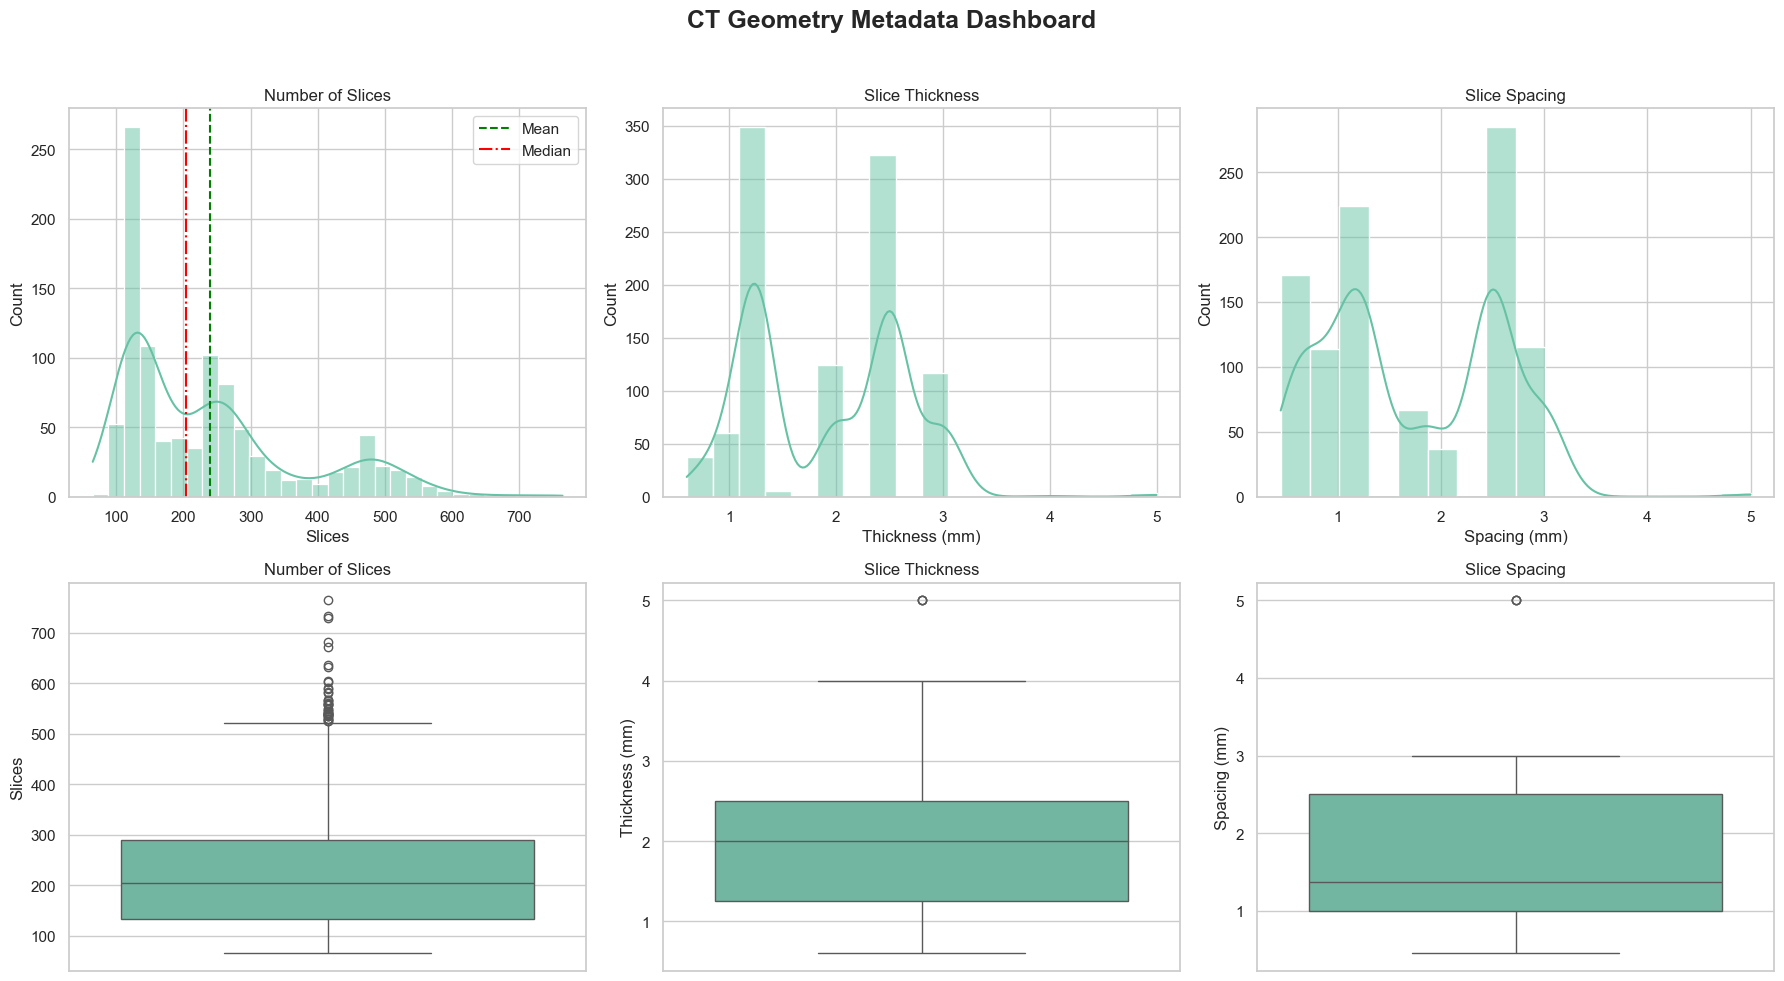

In [17]:
# Dashboard Layout
n_charts = 6
n_cols = 3
n_rows = math.ceil(n_charts / n_cols)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(6 * n_cols, 5 * n_rows)
)

fig.suptitle(
    "CT Geometry Metadata Dashboard",
    fontsize=18,
    fontweight="bold"
)

axes = axes.flatten()

# Number of Slices Distribution
sns.histplot(
    dicom_metadata_df["num_slices"],
    bins=30,
    kde=True,
    ax=axes[0]
)

axes[0].axvline(
    dicom_metadata_df["num_slices"].mean(),
    color="green",
    linestyle="--",
    label="Mean"
)

axes[0].axvline(
    dicom_metadata_df["num_slices"].median(),
    color="red",
    linestyle="-.",
    label="Median"
)

axes[0].set_title("Number of Slices")
axes[0].set_xlabel("Slices")
axes[0].set_ylabel("Count")
axes[0].legend()

# Slice Thickness Distribution
sns.histplot(
    dicom_metadata_df["slice_thickness_mm"],
    bins="auto",
    kde=True,
    ax=axes[1]
)

axes[1].set_title("Slice Thickness")
axes[1].set_xlabel("Thickness (mm)")
axes[1].set_ylabel("Count")

# Slice Spacing Distribution
sns.histplot(
    dicom_metadata_df["slice_spacing_mm"],
    bins="auto",
    kde=True,
    ax=axes[2]
)

axes[2].set_title("Slice Spacing")
axes[2].set_xlabel("Spacing (mm)")
axes[2].set_ylabel("Count")

# Boxplot: Number of Slices
sns.boxplot(
    y=dicom_metadata_df["num_slices"],
    ax=axes[3]
)

axes[3].set_title("Number of Slices")
axes[3].set_ylabel("Slices")

# Boxplot: Slice Thickness
sns.boxplot(
    y=dicom_metadata_df["slice_thickness_mm"],
    ax=axes[4]
)

axes[4].set_title("Slice Thickness")
axes[4].set_ylabel("Thickness (mm)")

# Boxplot: Slice Spacing
sns.boxplot(
    y=dicom_metadata_df["slice_spacing_mm"],
    ax=axes[5]
)

axes[5].set_title("Slice Spacing")
axes[5].set_ylabel("Spacing (mm)")

# Layout
plt.tight_layout(rect=[0, 0, 1, 0.96])

plt.show()

# Clustering

## Run PyLidc Clustering and Extract Information

In [18]:
# # Load All Scans
# scans = pl.query(pl.Scan).all()

# # Extract Cluster Metadata
# cluster_rows = []

# for patient_idx, scan in enumerate(tqdm(scans, desc="Extracting Cluster Metadata")):
#     clusters = scan.cluster_annotations()

#     for cluster_idx, cluster in enumerate(clusters):
#         # Consensus
#         cmask, cbbox, masks = consensus(
#             cluster,
#             clevel=0.5
#         )

#         y_slice, x_slice, z_slice = cbbox
#         # Consensus Slice List
#         consensus_slice_list = list(
#             range(z_slice.start, z_slice.stop)
#         )

#         bbox_height = y_slice.stop - y_slice.start
#         bbox_width = x_slice.stop - x_slice.start
#         bbox_depth = z_slice.stop - z_slice.start

#         bbox_volume = (
#             bbox_height
#             * bbox_width
#             * bbox_depth
#         )

#         consensus_voxels = int(cmask.sum())

#         mask_density = (
#             consensus_voxels / bbox_volume
#             if bbox_volume > 0 else np.nan
#         )

#         centroid_y = (y_slice.start + y_slice.stop) / 2
#         centroid_x = (x_slice.start + x_slice.stop) / 2
#         centroid_z = (z_slice.start + z_slice.stop) / 2

#         # Annotation IDs
#         annotation_ids = [ann.id for ann in cluster]

#         # Malignancy
#         malignancy = [ann.malignancy for ann in cluster]

#         # Geometry
#         diameter = [ann.diameter for ann in cluster]
#         volume = [ann.volume for ann in cluster]
#         surface_area = [ann.surface_area for ann in cluster]

#         # Semantic Features
#         subtlety = [ann.subtlety for ann in cluster]
#         internal_structure = [ann.internalStructure for ann in cluster]
#         calcification = [ann.calcification for ann in cluster]
#         sphericity = [ann.sphericity for ann in cluster]
#         margin = [ann.margin for ann in cluster]
#         lobulation = [ann.lobulation for ann in cluster]
#         spiculation = [ann.spiculation for ann in cluster]
#         texture = [ann.texture for ann in cluster]

#         # Save Metadata
#         cluster_rows.append({
#             # Study Information
#             "patient_idx": patient_idx,
#             "patient_id": scan.patient_id,
#             "study_instance_uid": scan.study_instance_uid,
#             "series_instance_uid": scan.series_instance_uid,

#             # Cluster Information
#             "cluster_id": cluster_idx,
#             "cluster_uid":
#                 f"{scan.patient_id}_cluster_{cluster_idx}",
#             "num_annotations": len(cluster),
#             "annotation_ids": annotation_ids,

#             # Consensus Information
#             "consensus_num_slices": cmask.shape[2],
#             "consensus_height": cmask.shape[0],
#             "consensus_width": cmask.shape[1],
#             "consensus_voxels": consensus_voxels,
#             "consensus_bbox_volume": bbox_volume,
#             "consensus_mask_density": mask_density,
#             "consensus_slice_list": consensus_slice_list,

#             # Bounding Box
#             "bbox_y_min": y_slice.start,
#             "bbox_y_max": y_slice.stop,
#             "bbox_x_min": x_slice.start,
#             "bbox_x_max": x_slice.stop,
#             "bbox_z_min": z_slice.start,
#             "bbox_z_max": z_slice.stop,
#             "bbox_height": bbox_height,
#             "bbox_width": bbox_width,
#             "bbox_depth": bbox_depth,

#             # Centroid
#             "centroid_y": centroid_y,
#             "centroid_x": centroid_x,
#             "centroid_z": centroid_z,

#             # Malignancy
#             "malignancy_scores": malignancy,
#             "malignancy_mean": np.mean(malignancy),
#             "malignancy_std": np.std(malignancy),
#             "malignancy_min": np.min(malignancy),
#             "malignancy_max": np.max(malignancy),
#             "malignancy_agreement":
#                 len(set(malignancy)) == 1,

#             # Geometry
#             "diameter_mean": np.mean(diameter),
#             "diameter_std": np.std(diameter),
#             "diameter_min": np.min(diameter),
#             "diameter_max": np.max(diameter),

#             "volume_mean": np.mean(volume),
#             "volume_std": np.std(volume),
#             "volume_min": np.min(volume),
#             "volume_max": np.max(volume),

#             "surface_area_mean": np.mean(surface_area),
#             "surface_area_std": np.std(surface_area),
#             "surface_area_min": np.min(surface_area),
#             "surface_area_max": np.max(surface_area),

#             # Semantic Features
#             "subtlety_mean": np.mean(subtlety),
#             "internal_structure_mean":
#                 np.mean(internal_structure),
#             "calcification_mean":
#                 np.mean(calcification),
#             "sphericity_mean":
#                 np.mean(sphericity),
#             "margin_mean":
#                 np.mean(margin),
#             "lobulation_mean":
#                 np.mean(lobulation),
#             "spiculation_mean":
#                 np.mean(spiculation),
#             "texture_mean":
#                 np.mean(texture)
#         })

# # Create DataFrame
# cluster_df = pd.DataFrame(cluster_rows)

# # Save CSV
# csv_path = "../../dataset/_lidc/000_metadata/cluster_metadata.csv"

# cluster_df.to_csv(
#     csv_path,
#     index=False
# )

# print("=" * 60)
# print(f"Total Patients : {cluster_df['patient_id'].nunique()}")
# print(f"Total Clusters : {len(cluster_df)}")
# print(f"CSV saved to   : {csv_path}")
# print("=" * 60)

# display(cluster_df.head())

## Load Data

In [19]:
cluster_metadata_df = pd.read_csv("../../dataset/_lidc/000_metadata/cluster_metadata.csv")

print(f"{'='*20} DataFrame Information {'='*20}")
cluster_metadata_df.info()
print(f"\n{'='*20} First 5 Rows Of A DataFrame {'='*20}")
display(cluster_metadata_df.head())

==================== DataFrame Information ====================
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2651 entries, 0 to 2650
Data columns (total 53 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   patient_idx              2651 non-null   int64  
 1   patient_id               2651 non-null   object 
 2   study_instance_uid       2651 non-null   object 
 3   series_instance_uid      2651 non-null   object 
 4   cluster_id               2651 non-null   int64  
 5   cluster_uid              2651 non-null   object 
 6   num_annotations          2651 non-null   int64  
 7   annotation_ids           2651 non-null   object 
 8   consensus_num_slices     2651 non-null   int64  
 9   consensus_height         2651 non-null   int64  
 10  consensus_width          2651 non-null   int64  
 11  consensus_voxels         2651 non-null   int64  
 12  consensus_bbox_volume    2651 non-null   int64  
 13  consensus_mask

,patient_idx,patient_id,study_instance_uid,series_instance_uid,cluster_id,cluster_uid,num_annotations,annotation_ids,consensus_num_slices,consensus_height,...,surface_area_min,surface_area_max,subtlety_mean,internal_structure_mean,calcification_mean,sphericity_mean,margin_mean,lobulation_mean,spiculation_mean,texture_mean
0,0,LIDC-IDRI-0078,1.3.6.1.4.1.14519.5.2.1.6279.6001.339170810277...,1.3.6.1.4.1.14519.5.2.1.6279.6001.303494235102...,0,LIDC-IDRI-0078_cluster_0,4,"[2, 6, 10, 13]",6,34,...,1035.254928,1360.254889,4.50,1.0,6.0,4.00,3.25,2.25,2.25,4.75
1,0,LIDC-IDRI-0078,1.3.6.1.4.1.14519.5.2.1.6279.6001.339170810277...,1.3.6.1.4.1.14519.5.2.1.6279.6001.303494235102...,1,LIDC-IDRI-0078_cluster_1,4,"[1, 5, 9, 12]",6,40,...,777.536323,1130.172711,4.75,1.0,6.0,4.00,2.75,3.00,2.25,4.50
2,0,LIDC-IDRI-0078,1.3.6.1.4.1.14519.5.2.1.6279.6001.339170810277...,1.3.6.1.4.1.14519.5.2.1.6279.6001.303494235102...,2,LIDC-IDRI-0078_cluster_2,1,[8],2,8,...,66.910605,66.910605,4.00,1.0,5.0,5.00,5.00,1.00,1.00,5.00
3,0,LIDC-IDRI-0078,1.3.6.1.4.1.14519.5.2.1.6279.6001.339170810277...,1.3.6.1.4.1.14519.5.2.1.6279.6001.303494235102...,3,LIDC-IDRI-0078_cluster_3,4,"[3, 4, 7, 11]",8,50,...,1650.898027,1994.684094,5.00,1.0,5.0,3.75,3.25,3.25,2.75,4.75
4,1,LIDC-IDRI-0069,1.3.6.1.4.1.14519.5.2.1.6279.6001.303241414168...,1.3.6.1.4.1.14519.5.2.1.6279.6001.131939324905...,0,LIDC-IDRI-0069_cluster_0,4,"[16, 18, 20, 22]",9,26,...,228.703978,521.668568,2.50,1.0,6.0,4.50,4.25,4.00,4.00,4.75


## Descriptive Statistics

In [20]:
cluster_metadata_df.describe()

,patient_idx,cluster_id,num_annotations,consensus_num_slices,consensus_height,consensus_width,consensus_voxels,consensus_bbox_volume,consensus_mask_density,bbox_y_min,...,surface_area_min,surface_area_max,subtlety_mean,internal_structure_mean,calcification_mean,sphericity_mean,margin_mean,lobulation_mean,spiculation_mean,texture_mean
count,2651.000000,2651.000000,2651.000000,2651.000000,2651.000000,2651.000000,2651.000000,2651.000000,2651.000000,2651.000000,...,2651.000000,2651.000000,2651.000000,2651.000000,2651.000000,2651.000000,2651.00000,2651.000000,2651.000000,2651.000000
mean,505.601283,2.158431,2.587326,5.961901,15.814032,15.806865,767.754055,4114.996228,0.250668,276.288193,...,323.491575,434.752759,3.661871,1.014347,5.672620,3.773685,3.86503,1.627295,1.534609,4.315742
std,301.336148,2.779538,1.249986,5.278048,10.512801,10.491346,2146.458892,13562.958204,0.083614,74.634217,...,620.122301,812.301843,1.076429,0.159966,0.856693,0.780759,1.08107,0.835827,0.841819,1.153934
min,0.000000,0.000000,1.000000,1.000000,5.000000,4.000000,5.000000,30.000000,0.004981,67.000000,...,9.744529,13.761003,1.000000,1.000000,2.500000,1.000000,1.00000,1.000000,1.000000,1.000000
25%,230.000000,0.000000,1.000000,3.000000,9.000000,9.000000,74.000000,288.000000,0.191042,217.000000,...,73.705838,91.145376,3.000000,1.000000,6.000000,3.000000,3.25000,1.000000,1.000000,4.000000
50%,497.000000,1.000000,3.000000,4.000000,12.000000,12.000000,148.000000,624.000000,0.245536,283.000000,...,117.614975,157.639525,4.000000,1.000000,6.000000,4.000000,4.00000,1.250000,1.000000,5.000000
75%,783.000000,3.000000,4.000000,7.000000,17.000000,18.000000,417.500000,1900.000000,0.303571,336.000000,...,251.580380,351.863407,4.500000,1.000000,6.000000,4.333333,4.75000,2.000000,1.750000,5.000000
max,1017.000000,22.000000,8.000000,57.000000,98.000000,86.000000,45329.000000,229824.000000,0.583333,464.000000,...,9026.567042,9026.567042,5.000000,5.000000,6.000000,5.000000,5.00000,5.000000,5.000000,5.000000


## Cluster Overview

In [21]:
# Cluster Overview
overview = pd.DataFrame({
    "Metric": [
        "Total Patients",
        "Total Studies",
        "Total Clusters",
        "Total Annotations",
        "Average Annotations per Cluster",
        "Minimum Annotations per Cluster",
        "Maximum Annotations per Cluster",
    ],
    "Value": [
        cluster_metadata_df["patient_id"].nunique(),
        cluster_metadata_df["study_instance_uid"].nunique(),
        len(cluster_metadata_df),
        cluster_metadata_df["num_annotations"].sum(),
        round(cluster_metadata_df["num_annotations"].mean(), 2),
        cluster_metadata_df["num_annotations"].min(),
        cluster_metadata_df["num_annotations"].max(),
    ]
})

display(overview)

,Metric,Value
0,Total Patients,875.00
1,Total Studies,883.00
2,Total Clusters,2651.00
3,Total Annotations,6859.00
4,Average Annotations per Cluster,2.59
5,Minimum Annotations per Cluster,1.00
6,Maximum Annotations per Cluster,8.00


In [22]:
# Verify Duplicate Studies in Cluster Metadata
duplicate_pairs = duplicate_ids_ct_df[
    ["patient_id", "study_instance_uid"]
].drop_duplicates()

cluster_pairs = cluster_metadata_df[
    ["patient_id", "study_instance_uid"]
].drop_duplicates()

verification = duplicate_pairs.merge(
    cluster_pairs,
    on=["patient_id", "study_instance_uid"],
    how="left",
    indicator=True,
)

missing = verification[verification["_merge"] == "left_only"]

print(f"Duplicate studies in CT metadata    : {len(duplicate_pairs)}")
print(f"Found in cluster metadata           : {(verification['_merge'] == 'both').sum()}")
print(f"Missing                             : {len(missing)}")

Duplicate studies in CT metadata    : 16
Found in cluster metadata           : 16
Missing                             : 0


- Out of 1,010 unique patients, 875 patients contained at least one clustered pulmonary nodule, whereas 135 patients had no clustered nodules.
- A total of 883 CT studies produced clustered nodules, preserving the original difference of eight additional studies due to patients with multiple CT examinations.
- Therefore, the clustering process excluded only studies without clustered nodules and did not alter the original patient–study relationship.

### Number of Cluster per Study

In [23]:
study_cluster_counts = (
    cluster_metadata_df
    .groupby(
        ["study_instance_uid", "patient_id"]
    )
    .size()
    .reset_index(name="num_clusters")
)

study_cluster_counts["num_clusters"].describe()

count    883.000000
mean       3.002265
std        2.637596
min        1.000000
25%        1.000000
50%        2.000000
75%        4.000000
max       23.000000
Name: num_clusters, dtype: float64

### Distribution of the number of clusters per study

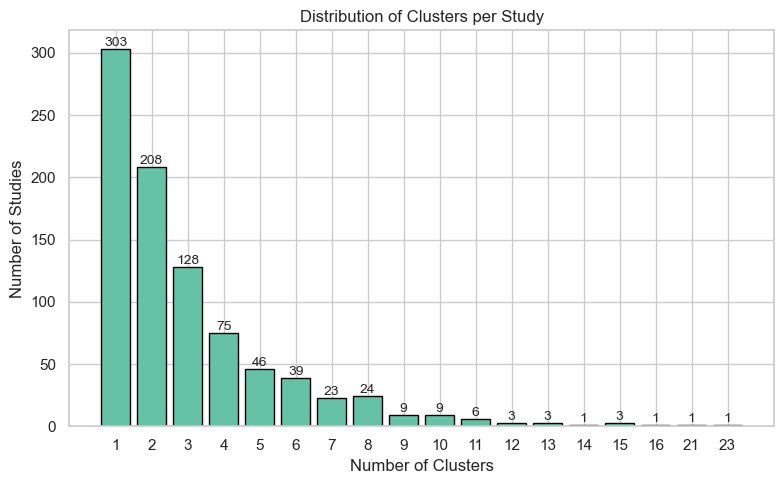

In [24]:
distribution = (
    study_cluster_counts["num_clusters"]
    .value_counts()
    .sort_index()
)

fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(
    distribution.index.astype(str),
    distribution.values,
    edgecolor="black"
)

ax.set_title("Distribution of Clusters per Study")
ax.set_xlabel("Number of Clusters")
ax.set_ylabel("Number of Studies")

# Add value labels
for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height}",
        ha="center",
        va="bottom",
        fontsize=10,
    )

plt.tight_layout()
plt.show()

### Studies without Clusters

In [25]:
studies_without_clusters = (
    ct_df[
        ~ct_df["study_instance_uid"].isin(
            cluster_metadata_df["study_instance_uid"]
        )
    ][
        ["patient_id", "study_instance_uid"]
    ]
    .sort_values(["patient_id", "study_instance_uid"])
    .reset_index(drop=True)
)

display(studies_without_clusters)

,patient_id,study_instance_uid
0,LIDC-IDRI-0028,1.3.6.1.4.1.14519.5.2.1.6279.6001.313822485916...
1,LIDC-IDRI-0032,1.3.6.1.4.1.14519.5.2.1.6279.6001.188500211166...
2,LIDC-IDRI-0062,1.3.6.1.4.1.14519.5.2.1.6279.6001.121427641977...
3,LIDC-IDRI-0071,1.3.6.1.4.1.14519.5.2.1.6279.6001.194873495479...
4,LIDC-IDRI-0100,1.3.6.1.4.1.14519.5.2.1.6279.6001.318037728418...
...,...,...
130,LIDC-IDRI-0975,1.3.6.1.4.1.14519.5.2.1.6279.6001.238406803970...
131,LIDC-IDRI-0979,1.3.6.1.4.1.14519.5.2.1.6279.6001.739936498619...
132,LIDC-IDRI-0988,1.3.6.1.4.1.14519.5.2.1.6279.6001.127337418291...
133,LIDC-IDRI-0992,1.3.6.1.4.1.14519.5.2.1.6279.6001.533848162484...


## EDA Dashboard - Cluster Geometry

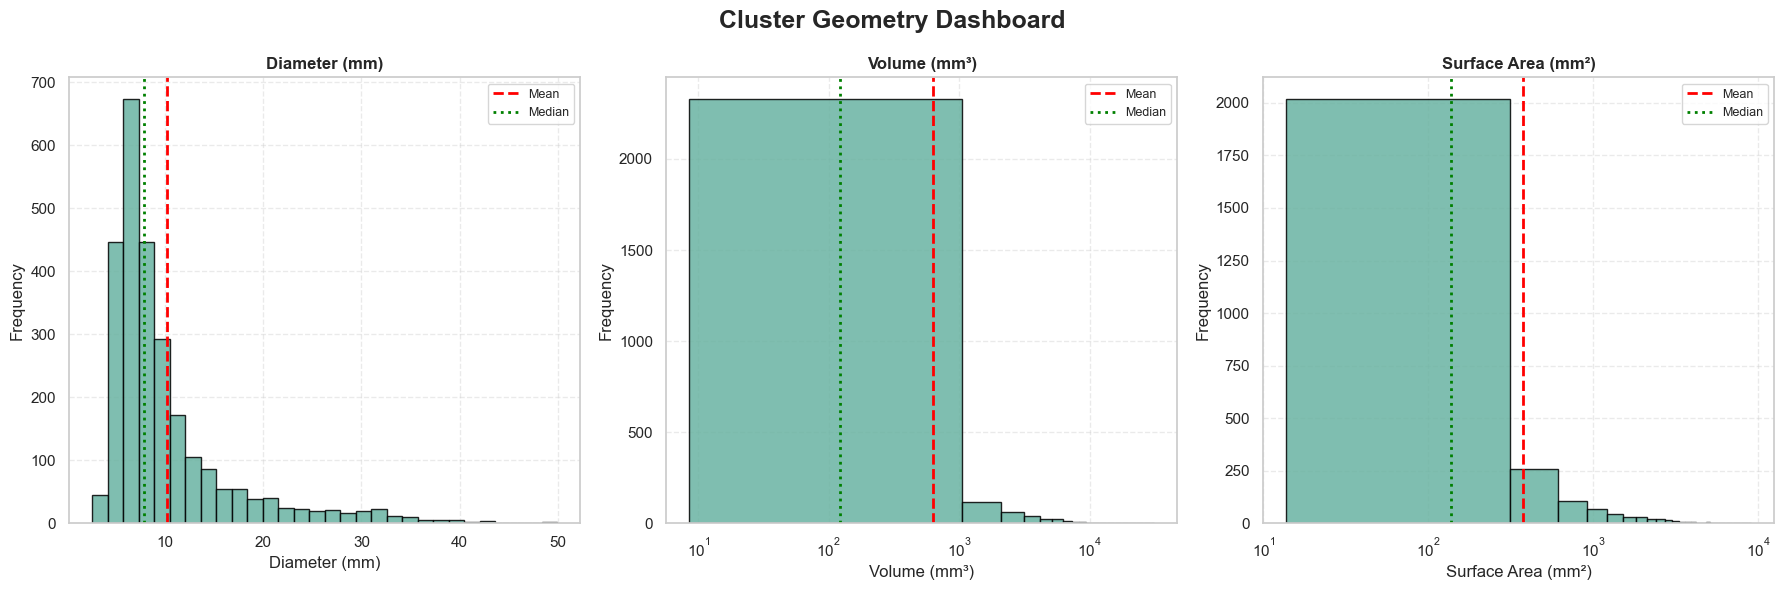

In [26]:
# Geometry features to visualize
geometry_features = [
    ("diameter_mean", "Diameter (mm)"),
    ("volume_mean", "Volume (mm³)"),
    ("surface_area_mean", "Surface Area (mm²)"),
    # ("consensus_bbox_volume", "Bounding Box Volume (voxels)"),
    # ("consensus_voxels", "Consensus Voxels"),
    # ("consensus_mask_density", "Mask Density"),
]

# Features displayed using logarithmic scale
log_scale_features = {
    "volume_mean",
    "surface_area_mean",
    # "consensus_bbox_volume",
    # "consensus_voxels",
}

# Create dashboard layout
n_cols = 3
n_rows = math.ceil(len(geometry_features) / n_cols)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(18, 6)
)

axes = axes.flatten()

# Plot each geometry feature
for ax, (column, title) in zip(axes, geometry_features):

    # Remove missing values
    data = cluster_metadata_df[column].dropna()

    # Plot histogram
    ax.hist(
        data,
        bins=30,
        color="#69b3a2",
        edgecolor="black",
        alpha=0.85
    )

    # Apply logarithmic x-axis for skewed features
    if column in log_scale_features:
        ax.set_xscale("log")

    # Calculate summary statistics
    mean = data.mean()
    median = data.median()

    # Draw mean line
    ax.axvline(
        mean,
        color="red",
        linestyle="--",
        linewidth=2,
        label="Mean"
    )

    # Draw median line
    ax.axvline(
        median,
        color="green",
        linestyle=":",
        linewidth=2,
        label="Median"
    )

    # Configure subplot
    ax.set_title(
        title,
        fontsize=12,
        fontweight="bold"
    )

    ax.set_xlabel(title)
    ax.set_ylabel("Frequency")

    ax.grid(
        linestyle="--",
        alpha=0.4
    )

    # Display legend
    ax.legend(
        loc="upper right",
        fontsize=9,
        frameon=True
    )

# Hide unused subplot(s)
for i in range(len(geometry_features), len(axes)):
    axes[i].axis("off")

# Figure title
plt.suptitle(
    "Cluster Geometry Dashboard",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout()

plt.show()

In [27]:
# Cluster Geometry Summary Statistics
geometry_columns = [
    "diameter_mean",
    "volume_mean",
    "surface_area_mean",
    "consensus_bbox_volume",
    "consensus_voxels",
    "consensus_mask_density",
]

display(
    cluster_metadata_df[geometry_columns]
    .describe()
    .round(2)
    .T
)

,count,mean,std,min,25%,50%,75%,max
diameter_mean,2651.0,10.16,6.73,2.59,6.13,7.82,11.14,49.94
volume_mean,2651.0,630.33,1779.43,8.54,63.63,122.42,323.06,31112.20
surface_area_mean,2651.0,375.66,695.36,13.76,84.09,137.67,299.77,9026.57
consensus_bbox_volume,2651.0,4115.00,13562.96,30.00,288.00,624.00,1900.00,229824.00
consensus_voxels,2651.0,767.75,2146.46,5.00,74.00,148.00,417.50,45329.00
consensus_mask_density,2651.0,0.25,0.08,0.00,0.19,0.25,0.30,0.58


In [28]:
# Count clusters based on the mean diameter threshold
diameter_threshold_table = (
    cluster_metadata_df["diameter_mean"]
    .lt(3)
    .map({
        True: "< 3 mm",
        False: "≥ 3 mm"
    })
    .value_counts()
    .reindex(["< 3 mm", "≥ 3 mm"])
    .rename_axis("Mean Diameter")
    .reset_index(name="Number of Clusters")
)

# Calculate percentage
diameter_threshold_table["Percentage (%)"] = (
    diameter_threshold_table["Number of Clusters"]
    / diameter_threshold_table["Number of Clusters"].sum()
    * 100
).round(2)

# Display table
display(diameter_threshold_table)

,Mean Diameter,Number of Clusters,Percentage (%)
0,< 3 mm,3,0.11
1,≥ 3 mm,2648,99.89


Among the 2,651 extracted clusters, 2,648 clusters (99.89%) had a mean diameter of at least 3 mm, while only three clusters (0.11%) had a mean diameter below 3 mm. Given the negligible proportion of clusters with a mean diameter below 3 mm and the inherent variability in diameter measurements among radiologists, no further diameter-based data selection was performed.

## EDA Dashboard - Consensus

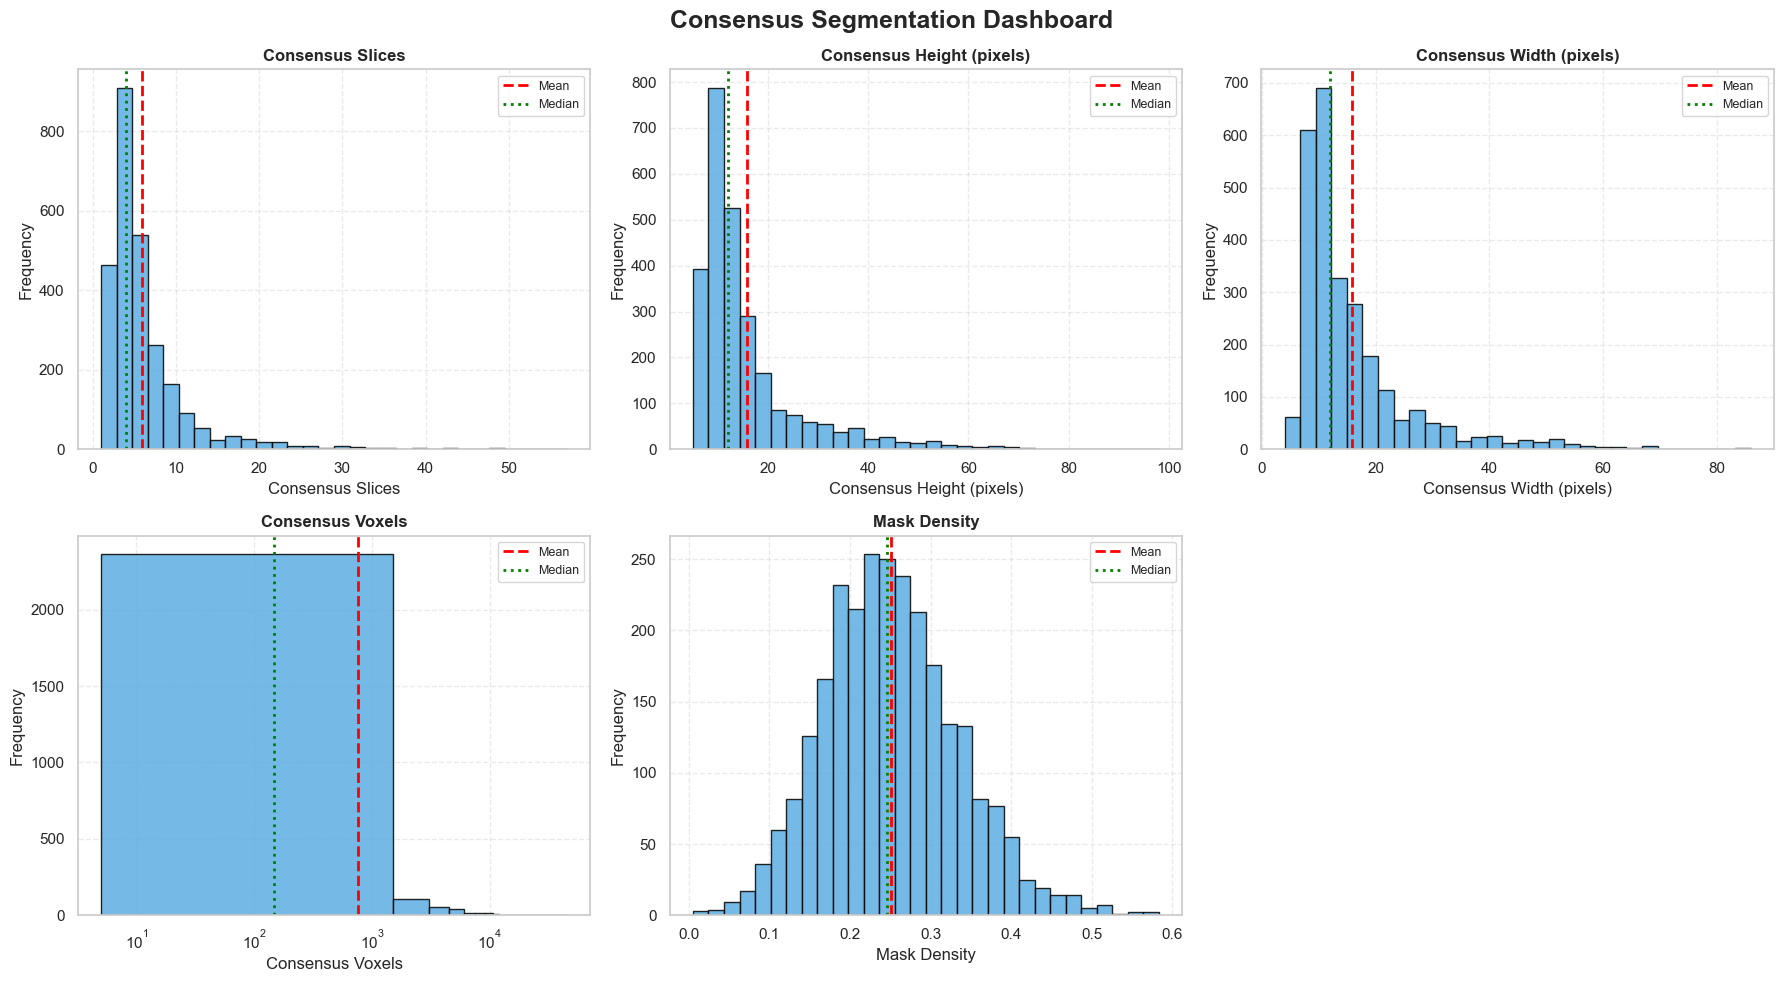

In [29]:
# Consensus features to visualize
consensus_features = [
    ("consensus_num_slices", "Consensus Slices"),
    ("consensus_height", "Consensus Height (pixels)"),
    ("consensus_width", "Consensus Width (pixels)"),
    ("consensus_voxels", "Consensus Voxels"),
    #("bbox_depth", "Bounding Box Depth (slices)"),
    ("consensus_mask_density", "Mask Density"),
]

# Features displayed using logarithmic scale
log_scale_features = {
    "consensus_voxels",
}

# Create dashboard layout
n_cols = 3
n_rows = math.ceil(len(consensus_features) / n_cols)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(18, 10)
)

axes = axes.flatten()

# Plot each consensus feature
for ax, (column, title) in zip(axes, consensus_features):

    # Remove missing values
    data = cluster_metadata_df[column].dropna()

    # Plot histogram
    ax.hist(
        data,
        bins=30,
        color="#5DADE2",
        edgecolor="black",
        alpha=0.85
    )

    # Apply logarithmic scale
    if column in log_scale_features:
        ax.set_xscale("log")

    # Calculate statistics
    mean = data.mean()
    median = data.median()

    # Mean
    ax.axvline(
        mean,
        color="red",
        linestyle="--",
        linewidth=2,
        label="Mean"
    )

    # Median
    ax.axvline(
        median,
        color="green",
        linestyle=":",
        linewidth=2,
        label="Median"
    )

    # Configure subplot
    ax.set_title(
        title,
        fontsize=12,
        fontweight="bold"
    )

    ax.set_xlabel(title)
    ax.set_ylabel("Frequency")

    ax.grid(
        linestyle="--",
        alpha=0.4
    )

    ax.legend(
        loc="upper right",
        fontsize=9
    )

# Hide unused subplot(s)
for i in range(len(consensus_features), len(axes)):
    axes[i].axis("off")

# Figure title
plt.suptitle(
    "Consensus Segmentation Dashboard",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout()

plt.show()

## EDA Dashboard - Malignancy

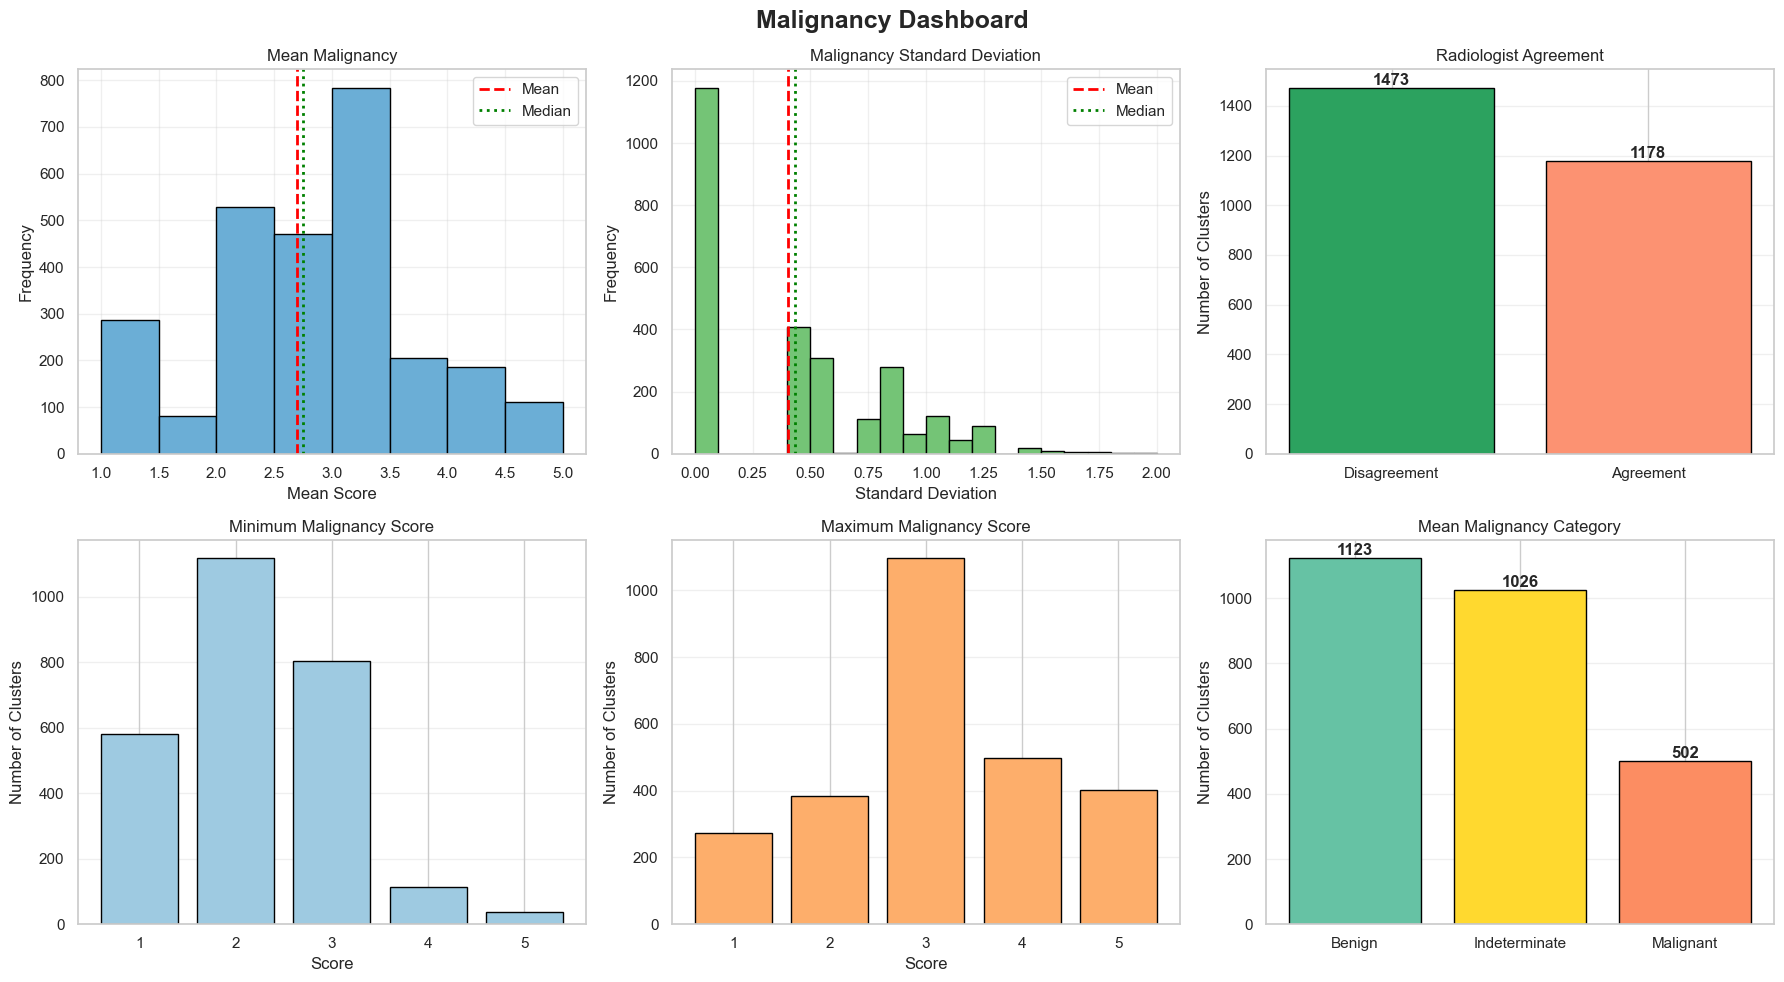

In [30]:
# Create dashboard layout
fig, axes = plt.subplots(
    2,
    3,
    figsize=(18, 10)
)

axes = axes.flatten()

# Mean Malignancy
data = cluster_metadata_df["malignancy_mean"]

axes[0].hist(
    data,
    bins=8,
    edgecolor="black",
    color="#6baed6"
)

axes[0].axvline(
    data.mean(),
    color="red",
    linestyle="--",
    linewidth=2,
    label="Mean"
)

axes[0].axvline(
    data.median(),
    color="green",
    linestyle=":",
    linewidth=2,
    label="Median"
)

axes[0].set_title("Mean Malignancy")
axes[0].set_xlabel("Mean Score")
axes[0].set_ylabel("Frequency")
axes[0].grid(alpha=0.3)
axes[0].legend()

# Malignancy Standard Deviation
data = cluster_metadata_df["malignancy_std"]

axes[1].hist(
    data,
    bins=20,
    edgecolor="black",
    color="#74c476"
)

axes[1].axvline(
    data.mean(),
    color="red",
    linestyle="--",
    linewidth=2,
    label="Mean"
)

axes[1].axvline(
    data.median(),
    color="green",
    linestyle=":",
    linewidth=2,
    label="Median"
)

axes[1].set_title("Malignancy Standard Deviation")
axes[1].set_xlabel("Standard Deviation")
axes[1].set_ylabel("Frequency")
axes[1].grid(alpha=0.3)
axes[1].legend()

# Malignancy Agreement
agreement = (
    cluster_metadata_df["malignancy_agreement"]
    .map({
        True: "Agreement",
        False: "Disagreement"
    })
    .value_counts()
)

bars = axes[2].bar(
    agreement.index,
    agreement.values,
    edgecolor="black",
    color=["#2ca25f", "#fc9272"]
)

for bar in bars:

    axes[2].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        int(bar.get_height()),
        ha="center",
        va="bottom",
        fontweight="bold"
    )

axes[2].set_title("Radiologist Agreement")
axes[2].set_ylabel("Number of Clusters")
axes[2].grid(axis="y", alpha=0.3)

# Minimum Malignancy
minimum = (
    cluster_metadata_df["malignancy_min"]
    .value_counts()
    .sort_index()
)

axes[3].bar(
    minimum.index.astype(str),
    minimum.values,
    edgecolor="black",
    color="#9ecae1"
)

axes[3].set_title("Minimum Malignancy Score")
axes[3].set_xlabel("Score")
axes[3].set_ylabel("Number of Clusters")
axes[3].grid(axis="y", alpha=0.3)

# Maximum Malignancy
maximum = (
    cluster_metadata_df["malignancy_max"]
    .value_counts()
    .sort_index()
)

axes[4].bar(
    maximum.index.astype(str),
    maximum.values,
    edgecolor="black",
    color="#fdae6b"
)

axes[4].set_title("Maximum Malignancy Score")
axes[4].set_xlabel("Score")
axes[4].set_ylabel("Number of Clusters")
axes[4].grid(axis="y", alpha=0.3)

# Mean Malignancy Category
def malignancy_category(score):
    if score <= 2.5:
        return "Benign"
    elif score >= 3.5:
        return "Malignant"

    return "Indeterminate"

category = (
    cluster_metadata_df["malignancy_mean"]
    .apply(malignancy_category)
    .value_counts()
    .reindex(["Benign", "Indeterminate", "Malignant"])
)

bars = axes[5].bar(
    category.index,
    category.values,
    edgecolor="black",
    color=["#66c2a4", "#ffd92f", "#fc8d62"]
)

for bar in bars:
    axes[5].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        int(bar.get_height()),
        ha="center",
        va="bottom",
        fontweight="bold"
    )

axes[5].set_title("Mean Malignancy Category")
axes[5].set_ylabel("Number of Clusters")
axes[5].grid(axis="y", alpha=0.3)


# Figure title
plt.suptitle(
    "Malignancy Dashboard",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout()

plt.show()

- The mean malignancy scores are concentrated between 2.5 and 3.5, indicating that most nodules were assigned intermediate malignancy ratings by the radiologists. Fewer nodules received very low (1–2) or very high (4–5) mean malignancy scores.
- Most clusters have a low standard deviation, indicating that radiologists generally showed good agreement when assigning malignancy scores. However, some clusters exhibit higher variability, reflecting differences in radiologists' assessments.
- Out of 2,651 clusters, 1,178 (44.44%) showed complete agreement among radiologists, while 1,473 (55.56%) showed some level of disagreement. This indicates that variability in malignancy assessment is common in the LIDC-IDRI dataset.
- Most clusters have a minimum malignancy score of 2 or 3, suggesting that at least one radiologist frequently assigned a low to intermediate malignancy rating. Only a small number of clusters received the highest minimum score of 5, indicating unanimous high suspicion of malignancy.
- The maximum malignancy score is most frequently 3, followed by 4 and 5, indicating that many clusters were considered moderately suspicious by at least one radiologist. Relatively few clusters had a maximum score of 1, showing that completely benign assessments were less common.
- Based on the mean malignancy score, the dataset contains 1,123 benign, 1,026 indeterminate, and 502 malignant clusters. The large number of indeterminate nodules supports the need for a data selection step that excludes ambiguous cases before model development.

# Data Selection

In [31]:
def assign_malignancy_label(mean_score):
    """
    Assign a malignancy label based on the mean malignancy score.
    """

    if mean_score <= 2.5:
        return "Benign"

    elif mean_score >= 3.5:
        return "Malignant"

    else:
        return "Indeterminate"


# Add malignancy label
cluster_metadata_df["label"] = (
    cluster_metadata_df["malignancy_mean"]
    .apply(assign_malignancy_label)
)

# Display label distribution
label_distribution = (
    cluster_metadata_df["label"]
    .value_counts()
    .reindex(["Benign", "Indeterminate", "Malignant"])
    .rename_axis("Label")
    .reset_index(name="Number of Clusters")
)

label_distribution["Percentage (%)"] = (
    label_distribution["Number of Clusters"]
    / len(cluster_metadata_df)
    * 100
).round(2)

display(label_distribution)

,Label,Number of Clusters,Percentage (%)
0,Benign,1123,42.36
1,Indeterminate,1026,38.70
2,Malignant,502,18.94


##  Remove Duplicate Studies

```
excluded_study_uids = [
    "1.3.6.1.4.1.14519.5.2.1.6279.6001.218658642102832118810712329678",  # LIDC-IDRI-0132
    "1.3.6.1.4.1.14519.5.2.1.6279.6001.222444895275634974977432374937",  # LIDC-IDRI-0151
    "1.3.6.1.4.1.14519.5.2.1.6279.6001.709924281509506265799179464374",  # LIDC-IDRI-0315
    "1.3.6.1.4.1.14519.5.2.1.6279.6001.124508094927772723365648607398",  # LIDC-IDRI-0332
    "1.3.6.1.4.1.14519.5.2.1.6279.6001.221138977753587043062153841454",  # LIDC-IDRI-0355
    "1.3.6.1.4.1.14519.5.2.1.6279.6001.216207548522622026268886920069",  # LIDC-IDRI-0365
    "1.3.6.1.4.1.14519.5.2.1.6279.6001.265657827498396379702226874113",  # LIDC-IDRI-0442
    "1.3.6.1.4.1.14519.5.2.1.6279.6001.202012743926377385386645171009",  # LIDC-IDRI-0484
]
```

In [32]:
num_clusters_before = len(cluster_metadata_df)

# Remove duplicate studies
cluster_metadata_df = cluster_metadata_df[
    ~cluster_metadata_df["study_instance_uid"].isin(excluded_study_uids)
].reset_index(drop=True)

# Dataset size after filtering
num_clusters_after = len(cluster_metadata_df)
num_removed = num_clusters_before - num_clusters_after

# Display summary
print(f"Clusters before filtering : {num_clusters_before:,}")
print(f"Clusters removed          : {num_removed:,}")
print(f"Clusters after filtering  : {num_clusters_after:,}")

Clusters before filtering : 2,651
Clusters removed          : 21
Clusters after filtering  : 2,630


## Remove Nodules Annotated by Fewer Than Three Radiologists

In [ ]:
num_clusters_before = len(cluster_metadata_df)

# Remove indeterminate nodules
cluster_metadata_df = cluster_metadata_df[
    cluster_metadata_df["label"] != "Indeterminate"
].reset_index(drop=True)

# Dataset size after filtering
num_clusters_after = len(cluster_metadata_df)
num_removed = num_clusters_before - num_clusters_after

# Display filtering summary
print(f"Clusters before filtering : {num_clusters_before:,}")
print(f"Clusters removed          : {num_removed:,}")
print(f"Clusters after filtering  : {num_clusters_after:,}")

# Display label distribution
label_distribution = (
    cluster_metadata_df["label"]
    .value_counts()
    .reindex(["Benign", "Malignant"])
    .rename_axis("Label")
    .reset_index(name="Number of Clusters")
)

label_distribution["Percentage (%)"] = (
    label_distribution["Number of Clusters"]
    / len(cluster_metadata_df)
    * 100
).round(2)

display(label_distribution)

Clusters before filtering : 2,630
Clusters removed          : 1,017
Clusters after filtering  : 1,613


,Label,Number of Clusters,Percentage (%)
0,Benign,1119,69.37
1,Malignant,494,30.63


## Remove Indeterminate Malignanacy

In [34]:
# Dataset size before filtering
num_clusters_before = len(cluster_metadata_df)

# Remove nodules with fewer than three annotations
cluster_metadata_df = cluster_metadata_df[
    cluster_metadata_df["num_annotations"] >= 3
].reset_index(drop=True)

# Dataset size after filtering
num_clusters_after = len(cluster_metadata_df)
num_removed = num_clusters_before - num_clusters_after

# Display filtering summary
print(f"Clusters before filtering : {num_clusters_before:,}")
print(f"Clusters removed          : {num_removed:,}")
print(f"Clusters after filtering  : {num_clusters_after:,}")

# Display annotation distribution
annotation_distribution = (
    cluster_metadata_df["num_annotations"]
    .value_counts()
    .sort_index()
    .rename_axis("Number of Radiologists")
    .reset_index(name="Number of Clusters")
)

annotation_distribution["Percentage (%)"] = (
    annotation_distribution["Number of Clusters"]
    / len(cluster_metadata_df)
    * 100
).round(2)

display(annotation_distribution)

Clusters before filtering : 1,613
Clusters removed          : 811
Clusters after filtering  : 802


,Number of Radiologists,Number of Clusters,Percentage (%)
0,3,225,28.05
1,4,568,70.82
2,5,6,0.75
3,6,1,0.12
4,7,2,0.25


In [35]:
cluster_metadata_df.to_csv(
    "../../dataset/_lidc/000_metadata/cluster_metadata_cleaned.csv",
    index=False
)